# pandas 그룹화 기능을 사용한 데이터 분석
 
-2016 US Election 데이터셋 분석하기

-dataset download : : https://drive.google.com/file/d/0B9fcvsgEhJNsN0FUaGZudFYyTVU/view

**2016 US Election 데이터셋의 주요 컬럼 요약**
 
**primary_results.csv**

 • state: state where the primary or caucus was held
 
 • state_abbreviation: two letter state abbreviation
 
 • county: county where the results come from
 
 • fips: FIPS county code
 
 • party: Democrat or Republican
 
 • candidate: name of the candidate
 
 • votes: number of votes the candidate received in the corresponding state and county (may be missing)
 
 • fraction_votes: fraction of votes the president received in the corresponding state, county, and primary
  
**county_facts.csv**

 • "RHI125214: White alone, percent, 2014
 
 • "RHI225214": Black or African American alone, percent, 2014
 
 • "RHI325214": "American Indian and Alaska Native alone, percent, 2014
 
 • "RHI425214": Asian alone, percent, 2014
 
 • "RHI525214": Native Hawaiian and Other Pacific Islander alone, percent, 2014
 
 • "RHI625214": Two or More Races, percent, 2014
 
 • "RHI725214": Hispanic or Latino, percent, 2014
 
 • "RHI825214": White alone, not Hispanic or Latino, percent, 2014
  
(기타 컬럼 생략)
 
* 참고: https://www.kaggle.com/benhamner/2016-us-election


In [1]:
%matplotlib nbagg
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib

### 각 후보 별 전체 득표수 계산하기

In [3]:
primary = pd.read_csv('data/2016_presidential_election/primary_results.csv', sep=',')

In [4]:
counties = pd.read_csv('data/2016_presidential_election/county_facts.csv', sep=',')

In [5]:
primary.head()

,state,state_abbreviation,county,fips,party,candidate,votes,fraction_votes
0,Alabama,AL,Autauga,1001,Republican,Donald Trump,5387,0.445
1,Alabama,AL,Autauga,1001,Republican,Ted Cruz,2482,0.205
2,Alabama,AL,Autauga,1001,Republican,Marco Rubio,1785,0.148
3,Alabama,AL,Autauga,1001,Republican,Ben Carson,1764,0.146
4,Alabama,AL,Autauga,1001,Republican,John Kasich,421,0.035


In [6]:
primary[['state', 'county', 'fips']]

,state,county,fips
0,Alabama,Autauga,1001
1,Alabama,Autauga,1001
2,Alabama,Autauga,1001
3,Alabama,Autauga,1001
4,Alabama,Autauga,1001
5,Alabama,Autauga,1001
6,Alabama,Autauga,1001
7,Alabama,Baldwin,1003
8,Alabama,Baldwin,1003
9,Alabama,Baldwin,1003


In [7]:
counties.head()

,fips,area_name,state_abbreviation,PST045214,PST040210,PST120214,POP010210,AGE135214,AGE295214,AGE775214,...,SBO415207,SBO015207,MAN450207,WTN220207,RTN130207,RTN131207,AFN120207,BPS030214,LND110210,POP060210
0,0,United States,NaN,318857056,308758105,3.3,308745538,6.2,23.1,14.5,...,8.3,28.8,5319456312,4174286516,3917663456,12990,613795732,1046363,3531905.43,87.4
1,1000,Alabama,NaN,4849377,4780127,1.4,4779736,6.1,22.8,15.3,...,1.2,28.1,112858843,52252752,57344851,12364,6426342,13369,50645.33,94.4
2,1001,Autauga County,AL,55395,54571,1.5,54571,6.0,25.2,13.8,...,0.7,31.7,0,0,598175,12003,88157,131,594.44,91.8
3,1003,Baldwin County,AL,200111,182265,9.8,182265,5.6,22.2,18.7,...,1.3,27.3,1410273,0,2966489,17166,436955,1384,1589.78,114.6
4,1005,Barbour County,AL,26887,27457,-2.1,27457,5.7,21.2,16.5,...,0.0,27.0,0,0,188337,6334,0,8,884.88,31.0


In [8]:
primary.columns

Index(['state', 'state_abbreviation', 'county', 'fips', 'party', 'candidate',
       'votes', 'fraction_votes'],
      dtype='object')

In [9]:
primary.shape

(13212, 8)

In [10]:
counties.columns

Index(['fips', 'area_name', 'state_abbreviation', 'PST045214', 'PST040210',
       'PST120214', 'POP010210', 'AGE135214', 'AGE295214', 'AGE775214',
       'SEX255214', 'RHI125214', 'RHI225214', 'RHI325214', 'RHI425214',
       'RHI525214', 'RHI625214', 'RHI725214', 'RHI825214', 'POP715213',
       'POP645213', 'POP815213', 'EDU635213', 'EDU685213', 'VET605213',
       'LFE305213', 'HSG010214', 'HSG445213', 'HSG096213', 'HSG495213',
       'HSD410213', 'HSD310213', 'INC910213', 'INC110213', 'PVY020213',
       'BZA010213', 'BZA110213', 'BZA115213', 'NES010213', 'SBO001207',
       'SBO315207', 'SBO115207', 'SBO215207', 'SBO515207', 'SBO415207',
       'SBO015207', 'MAN450207', 'WTN220207', 'RTN130207', 'RTN131207',
       'AFN120207', 'BPS030214', 'LND110210', 'POP060210'],
      dtype='object')

In [11]:
counties.shape

(3195, 54)

In [12]:
primary['candidate'].unique()

array(['Donald Trump', 'Ted Cruz', 'Marco Rubio', 'Ben Carson',
       'John Kasich', 'Hillary Clinton', 'Bernie Sanders',
       'Carly Fiorina', 'Rand Paul', 'Mike Huckabee', 'Rick Santorum',
       'Jeb Bush', 'Chris Christie', "Martin O'Malley", ' Uncommitted',
       ' No Preference'], dtype=object)

In [14]:
primary.groupby('candidate')['votes'].sum()

candidate
 No Preference         313
 Uncommitted            43
Ben Carson          528463
Bernie Sanders     4740278
Carly Fiorina        15181
Chris Christie       24347
Donald Trump       6944654
Hillary Clinton    7178257
Jeb Bush             94394
John Kasich        2456406
Marco Rubio        2998335
Martin O'Malley        747
Mike Huckabee         3300
Rand Paul             8460
Rick Santorum         1773
Ted Cruz           5248807
Name: votes, dtype: int64

In [15]:
candidate_to_votes_s = primary.groupby('candidate')['votes'].sum().sort_values()
candidate_to_votes_s

candidate
 Uncommitted            43
 No Preference         313
Martin O'Malley        747
Rick Santorum         1773
Mike Huckabee         3300
Rand Paul             8460
Carly Fiorina        15181
Chris Christie       24347
Jeb Bush             94394
Ben Carson          528463
John Kasich        2456406
Marco Rubio        2998335
Bernie Sanders     4740278
Ted Cruz           5248807
Donald Trump       6944654
Hillary Clinton    7178257
Name: votes, dtype: int64

<IPython.core.display.Javascript object>


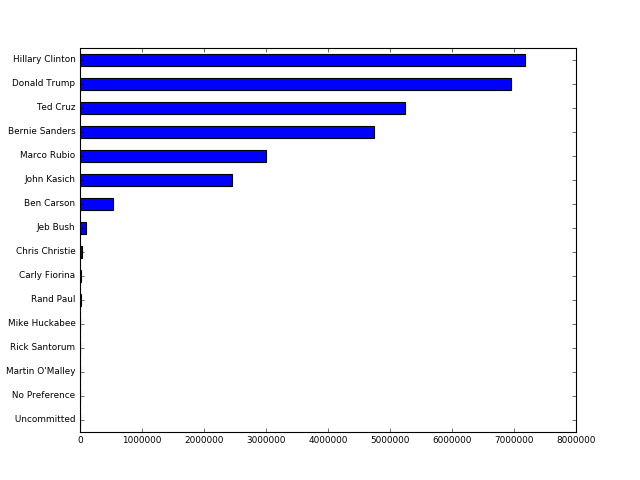

In [16]:
candidate_to_votes_s.plot(kind='barh', fontsize=8)

### 각 주별, 각 정당의 득표 비율 계산하기

In [17]:
primary.head()

,state,state_abbreviation,county,fips,party,candidate,votes,fraction_votes
0,Alabama,AL,Autauga,1001,Republican,Donald Trump,5387,0.445
1,Alabama,AL,Autauga,1001,Republican,Ted Cruz,2482,0.205
2,Alabama,AL,Autauga,1001,Republican,Marco Rubio,1785,0.148
3,Alabama,AL,Autauga,1001,Republican,Ben Carson,1764,0.146
4,Alabama,AL,Autauga,1001,Republican,John Kasich,421,0.035


In [18]:
state_party_to_votes_s = primary.groupby(['state','party'])['votes'].sum()

In [19]:
state_party_to_votes_s.head()

state     party     
Alabama   Democrat      381810
          Republican    805814
Arizona   Democrat      399097
          Republican    435103
Arkansas  Democrat      207182
Name: votes, dtype: int64

In [20]:
state_to_votes_s = primary.groupby('state')['votes'].sum()
state_to_votes_s.head()

state
Alabama     1187624
Arizona      834200
Arkansas     602290
Colorado     121184
Florida     3767915
Name: votes, dtype: int64

In [22]:
# 각 주별, 정당의 비율
state_party_to_vote_pcts_s = (state_party_to_votes_s / state_to_votes_s) * 100
state_party_to_vote_pcts_s.head()

state     party     
Alabama   Democrat      32.149064
          Republican    67.850936
Arizona   Democrat      47.841884
          Republican    52.158116
Arkansas  Democrat      34.399044
Name: votes, dtype: float64

<IPython.core.display.Javascript object>


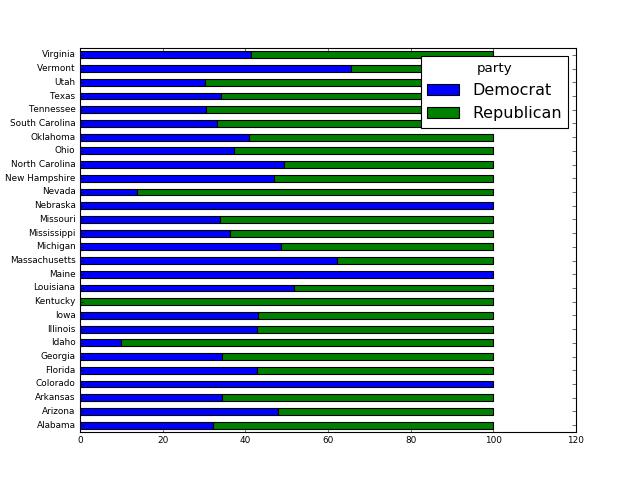

In [23]:
state_party_to_vote_pcts_s.unstack().plot(kind='barh', stacked = True, fontsize=8)

### 각 후보가 당선된 county의 평균 백인 유권자 비율 조사하기

In [24]:
func = lambda agg_df: agg_df.sort_values('votes',ascending=False).iloc[0]  # ascending : 내림차순정렬, agg_df : 그룹화된 dataframe

In [25]:
primary.head()

,state,state_abbreviation,county,fips,party,candidate,votes,fraction_votes
0,Alabama,AL,Autauga,1001,Republican,Donald Trump,5387,0.445
1,Alabama,AL,Autauga,1001,Republican,Ted Cruz,2482,0.205
2,Alabama,AL,Autauga,1001,Republican,Marco Rubio,1785,0.148
3,Alabama,AL,Autauga,1001,Republican,Ben Carson,1764,0.146
4,Alabama,AL,Autauga,1001,Republican,John Kasich,421,0.035


In [26]:
winners = primary.groupby("fips").agg(func)

In [27]:
winners.head()

,state,state_abbreviation,county,party,candidate,votes,fraction_votes
fips,,,,,,,
1001,Alabama,AL,Autauga,Republican,Donald Trump,5387,0.445
1003,Alabama,AL,Baldwin,Republican,Donald Trump,23618,0.469
1005,Alabama,AL,Barbour,Democrat,Hillary Clinton,2567,0.906
1007,Alabama,AL,Bibb,Republican,Donald Trump,1959,0.494
1009,Alabama,AL,Blount,Republican,Donald Trump,7390,0.487


In [28]:
winners_county_races = pd.merge(winners, counties[["fips", "RHI825214"]], 
                                left_index=True, right_on="fips", how="left")

In [29]:
winners_county_races = winners_county_races.rename(columns={"RHI825214":"white_pcts"})

In [30]:
winners_county_races.head()

,state,state_abbreviation,county,party,candidate,votes,fraction_votes,fips,white_pcts
2,Alabama,AL,Autauga,Republican,Donald Trump,5387,0.445,1001,75.6
3,Alabama,AL,Baldwin,Republican,Donald Trump,23618,0.469,1003,83.0
4,Alabama,AL,Barbour,Democrat,Hillary Clinton,2567,0.906,1005,46.6
5,Alabama,AL,Bibb,Republican,Donald Trump,1959,0.494,1007,74.5
6,Alabama,AL,Blount,Republican,Donald Trump,7390,0.487,1009,87.8


In [31]:
winners_county_white_pcts = winners_county_races.groupby(["party", "candidate"])["white_pcts"].mean()

In [32]:
winners_county_white_pcts.head()

party       candidate      
Democrat    Bernie Sanders     81.944030
            Hillary Clinton    56.856920
Republican  Ben Carson         81.100000
            Donald Trump       83.235638
            John Kasich        89.226415
Name: white_pcts, dtype: float64

<IPython.core.display.Javascript object>


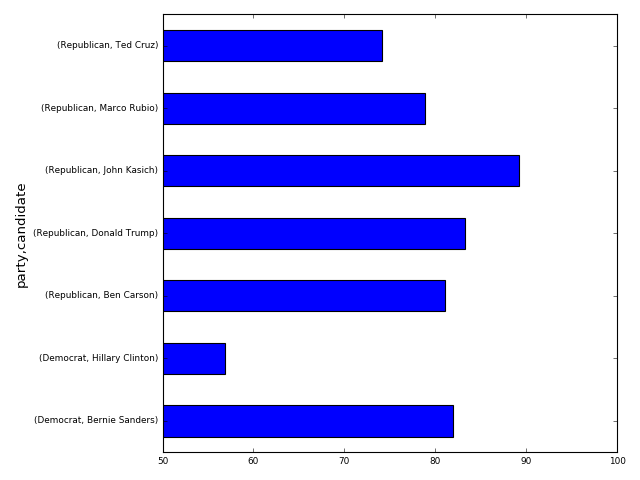

In [35]:
ax = winners_county_white_pcts.plot(kind="barh", fontsize=8)

In [36]:
ax.set_xlim([50, 100])

(50, 100)

In [37]:
plt.tight_layout()

### Pivot Table 사용하기
 
**'피벗 테이블(pivot table)'**을 사용하면, 데이터셋에 대하여 그룹화에 기반한 통계량을 계산하는 작업이 더 간편해진다. 
 
피벗 테이블은 df.pivot_table() 함수를 사용하여 생성한다. values 인자로는 통계량을 계산할 열을, index와 columns 인자는 각각 그 값을 피벗 테이블의 인덱스와 컬럼으로 사용할 열을, aggfunc 인자로는 적용할 통계 함수를 명시.


In [59]:
total_votes = primary.pivot_table(values="votes", index="state", 
                                  columns="candidate", aggfunc="sum", 
                                  fill_value=0)

In [60]:
total_votes.head()

candidate,No Preference,Uncommitted,Ben Carson,Bernie Sanders,Carly Fiorina,Chris Christie,Donald Trump,Hillary Clinton,Jeb Bush,John Kasich,Marco Rubio,Martin O'Malley,Mike Huckabee,Rand Paul,Rick Santorum,Ted Cruz
state,,,,,,,,,,,,,,,,
Alabama,0,0,84139,74987,0,0,356892,306823,0,37127,154379,0,0,0,0,173277
Arizona,0,0,0,163400,0,0,249916,235697,0,53040,0,0,0,0,0,132147
Arkansas,0,0,23105,64514,0,0,132546,142668,0,15079,100999,0,0,0,0,123379
Colorado,0,0,0,71928,0,0,0,49256,0,0,0,0,0,0,0,0
Florida,0,0,0,547051,0,0,1015451,1064566,0,150167,607491,0,0,0,0,383189


예를 들어 total_votes라는 피벗 테이블은 "state"와 "candidate" 열의 값을 그룹화 기준으로 하여, "votes" 열의 값의 합계를 산출한 결과이다. 이 때 fill_value=0 인자를 넣어주면, NaN이 나올 부분이 0으로 대체된다. 피벗 테이블도 DataFrame 형태를 지님.
 
혹은 다음과 같이 하면 "state_abbreviation"과 "party" 열의 값을 그룹화 기준으로 하여, "fraction_votes" 열의 값의 평균을 나타내는 피벗 테이블을 만들 수 있다.


In [61]:
primary.pivot_table(values="fraction_votes", index="state_abbreviation", 
                    columns="party", aggfunc="mean")

party,Democrat,Republican
state_abbreviation,,
AL,0.476823,0.195277
AR,0.464784,0.191924
AZ,0.478433,0.283867
CO,0.481016,NaN
FL,0.469349,0.242413
GA,0.493525,0.196939
IA,0.250003,0.090857
ID,0.494733,0.240773
IL,0.489632,0.242013
